In [3]:
!pip install seaborn yfinance

In [2]:
# ============================================================
# STEP 1: Imports, Stock Universe, and Data Download
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ---- 24-stock universe across 6 sectors (NSE tickers) ----
sector_map = {
    # IT (5)
    'TCS.NS': 'IT', 'INFY.NS': 'IT', 'HCLTECH.NS': 'IT', 'WIPRO.NS': 'IT', 'TECHM.NS': 'IT',
    # Banking / Financial Services (5)
    'HDFCBANK.NS': 'Banking', 'ICICIBANK.NS': 'Banking', 'SBIN.NS': 'Banking',
    'KOTAKBANK.NS': 'Banking', 'AXISBANK.NS': 'Banking',
    # FMCG (5)
    'HINDUNILVR.NS': 'FMCG', 'ITC.NS': 'FMCG', 'NESTLEIND.NS': 'FMCG',
    'BRITANNIA.NS': 'FMCG', 'DABUR.NS': 'FMCG',
    # Auto (3)
    'MARUTI.NS': 'Auto', 'M&M.NS': 'Auto', 'BAJAJ-AUTO.NS': 'Auto',
    # Pharma (3)
    'SUNPHARMA.NS': 'Pharma', 'DRREDDY.NS': 'Pharma', 'CIPLA.NS': 'Pharma',
    # Energy (3)
    'RELIANCE.NS': 'Energy', 'ONGC.NS': 'Energy', 'NTPC.NS': 'Energy',
}

tickers = list(sector_map.keys())
print(f"Total stocks: {len(tickers)}")
print(f"Sectors: {sorted(set(sector_map.values()))}")

# ---- Date range: 10 years ----
end_date = datetime.today()
start_date = end_date - timedelta(days=10*365)

print(f"\nDownloading data from {start_date.date()} to {end_date.date()} ...")

# ---- Download adjusted close prices ----
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=True)
prices = raw_data['Close']  # with auto_adjust=True, 'Close' is already adjusted

# ---- Basic cleaning ----
print(f"\nRaw shape: {prices.shape}")
missing_pct = prices.isna().mean().sort_values(ascending=False)
print("\nMissing % by stock (top 5):")
print(missing_pct.head())

# Drop any stock with >5% missing data, forward-fill the rest
good_tickers = missing_pct[missing_pct <= 0.05].index.tolist()
prices = prices[good_tickers].ffill().dropna()

print(f"\nFinal cleaned shape: {prices.shape}")
print(f"Stocks retained: {len(good_tickers)} / {len(tickers)}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

prices.head()

Total stocks: 24
Sectors: ['Auto', 'Banking', 'Energy', 'FMCG', 'IT', 'Pharma']



[*********************100%***********************]  24 of 24 completed



Raw shape: (2471, 24)

Missing % by stock (top 5):
Ticker
AXISBANK.NS     0.0000
BAJAJ-AUTO.NS   0.0000
BRITANNIA.NS    0.0000
CIPLA.NS        0.0000
DABUR.NS        0.0000
dtype: float64

Final cleaned shape: (2471, 24)
Stocks retained: 24 / 24
Date range: 2016-08-18 to 2026-08-14


Ticker,AXISBANK.NS,BAJAJ-AUTO.NS,BRITANNIA.NS,CIPLA.NS,DABUR.NS,DRREDDY.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,MARUTI.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TECHM.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-08-18,583.7609,2283.9910,1440.6597,512.7796,270.7239,565.6962,293.7956,285.5790,772.1329,217.2826,...,4443.6768,295.8059,96.3888,94.5543,222.0521,223.1267,722.8675,1037.3444,338.3163,88.4427
2016-08-19,579.2337,2273.9900,1449.7030,516.6302,268.5291,562.5100,292.3187,284.3478,775.3256,218.1418,...,4429.4390,297.1464,96.3599,94.6522,221.3651,232.1991,718.2856,1023.5645,340.9825,87.6005
2016-08-22,571.0650,2267.5554,1457.8375,517.3725,264.9458,563.0427,288.7295,285.0774,791.8428,216.7242,...,4373.0776,299.7083,94.5686,93.7708,220.6998,228.8755,705.7307,1002.0200,336.0464,86.8257
2016-08-23,573.2794,2231.8164,1454.4194,515.5633,260.5113,562.3325,295.7399,285.3396,784.7335,214.9629,...,4369.5073,300.8368,91.8814,93.3986,220.3944,228.8306,698.6284,1022.6011,335.6501,87.5163
2016-08-24,574.1652,2224.7612,1485.3999,526.2799,263.2884,568.0508,295.4967,287.6995,782.7754,213.4593,...,4473.2344,301.1593,93.2105,94.4172,222.5865,228.5163,705.3640,1011.1998,336.5509,87.5247


Working with 24 stocks
=== Individual Stock Stats (10Y Annualized) ===
                Sector  Ann_Return_%  Ann_Volatility_%  Return/Risk
Ticker                                                             
ICICIBANK.NS   Banking       23.4100           29.2500       0.8000
RELIANCE.NS     Energy       21.7600           27.0600       0.8000
M&M.NS            Auto       21.3800           30.5500       0.7000
SBIN.NS        Banking       20.9900           31.8400       0.6600
TECHM.NS            IT       20.3400           29.1800       0.7000
BAJAJ-AUTO.NS     Auto       19.9000           25.3900       0.7800
HCLTECH.NS          IT       19.1400           26.4600       0.7200
NESTLEIND.NS      FMCG       18.9400           21.8700       0.8700
BRITANNIA.NS      FMCG       16.4100           22.9400       0.7200
NTPC.NS         Energy       16.2000           25.8000       0.6300
MARUTI.NS         Auto       15.3400           27.4100       0.5600
INFY.NS             IT       14.9100         

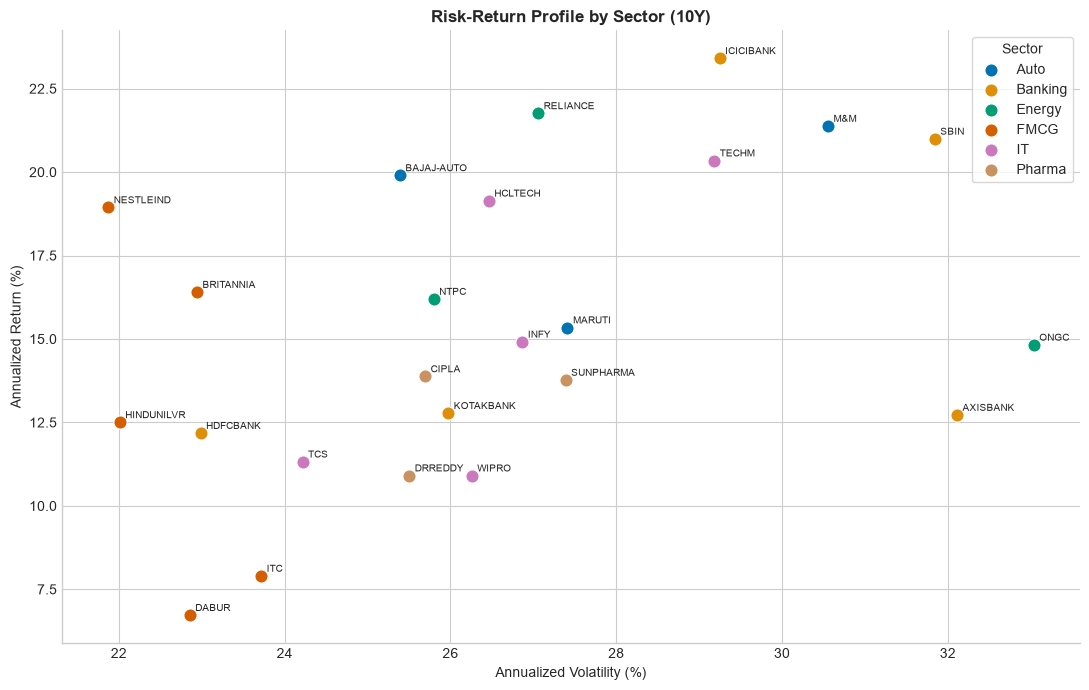

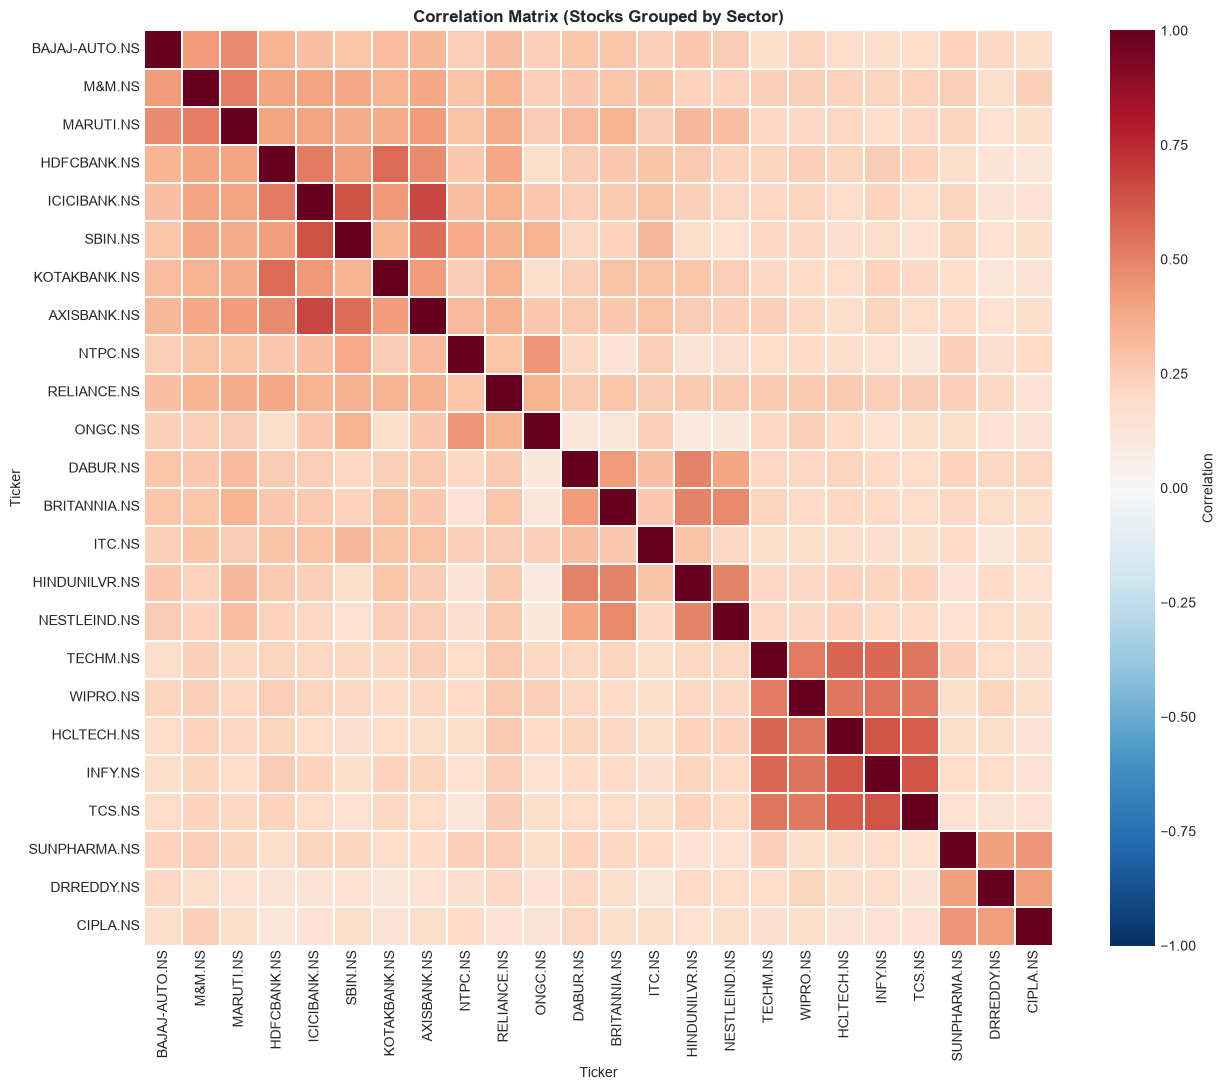


Daily returns shape: (2470, 24)


In [3]:
# ============================================================
# STEP 2: Daily Returns, Annualized Stats, Sector Analysis
# ============================================================

# ---- Update sector_map and tickers to match what actually downloaded ----
final_tickers = prices.columns.tolist()
sector_map = {t: s for t, s in sector_map.items() if t in final_tickers}
print(f"Working with {len(final_tickers)} stocks")

# ---- Daily simple returns ----
daily_returns = prices.pct_change().dropna()

# ---- Annualized return & volatility per stock (252 trading days) ----
TRADING_DAYS = 252
ann_return = daily_returns.mean() * TRADING_DAYS
ann_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)

stock_stats = pd.DataFrame({
    'Sector': [sector_map[t] for t in ann_return.index],
    'Ann_Return_%': ann_return * 100,
    'Ann_Volatility_%': ann_vol * 100,
    'Return/Risk': ann_return / ann_vol
}).sort_values('Ann_Return_%', ascending=False)

print("=== Individual Stock Stats (10Y Annualized) ===")
print(stock_stats.round(2))

# ---- Covariance & correlation matrix (annualized) ----
cov_matrix = daily_returns.cov() * TRADING_DAYS
corr_matrix = daily_returns.corr()

# ============================================================
# SECTOR-WISE ANALYSIS
# ============================================================
sector_series = pd.Series(sector_map)

sector_stats = stock_stats.groupby('Sector').agg(
    Avg_Return_pct=('Ann_Return_%', 'mean'),
    Avg_Volatility_pct=('Ann_Volatility_%', 'mean'),
    Num_Stocks=('Ann_Return_%', 'count')
).round(2).sort_values('Avg_Return_pct', ascending=False)

print("\n=== Sector-Wise Summary ===")
print(sector_stats)

# ---- Plot 1: Risk-Return scatter colored by sector ----
fig, ax = plt.subplots(figsize=(11, 7))
sectors_unique = sorted(sector_series.unique())
palette = dict(zip(sectors_unique, sns.color_palette("colorblind", len(sectors_unique))))

for sector in sectors_unique:
    stocks_in_sector = stock_stats[stock_stats['Sector'] == sector]
    ax.scatter(stocks_in_sector['Ann_Volatility_%'], stocks_in_sector['Ann_Return_%'],
               label=sector, s=90, color=palette[sector], edgecolor='white', linewidth=0.8)
    for name, row in stocks_in_sector.iterrows():
        ax.annotate(name.replace('.NS',''), (row['Ann_Volatility_%'], row['Ann_Return_%']),
                    fontsize=7.5, xytext=(4,3), textcoords='offset points')

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Risk-Return Profile by Sector (10Y)', fontweight='bold')
ax.legend(title='Sector', loc='best', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('sector_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Correlation heatmap, stocks ordered by sector ----
order = sector_series.sort_values().index.tolist()
order = [t for t in order if t in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix.loc[order, order], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix (Stocks Grouped by Sector)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDaily returns shape: {daily_returns.shape}")

=== Minimum Variance Portfolio (MVP) ===
Expected Annual Return: 13.27%
Annual Volatility:      13.06%
Sharpe Ratio:           0.52

=== Maximum Sharpe Portfolio (MSP) ===
Expected Annual Return: 20.13%
Annual Volatility:      15.66%
Sharpe Ratio:           0.87

=== Portfolio Weights (sorted by MSP allocation) ===
                Sector  MVP_Weight_%  MSP_Weight_%
NESTLEIND.NS      FMCG       11.2900       25.2800
ICICIBANK.NS   Banking        0.0000       16.6800
BAJAJ-AUTO.NS     Auto        4.2300       14.3400
RELIANCE.NS     Energy        0.0000       13.8600
HCLTECH.NS          IT        1.2200       10.2600
TECHM.NS            IT        0.0000        8.4400
NTPC.NS         Energy        8.6200        3.7800
CIPLA.NS        Pharma        8.3600        3.6900
M&M.NS            Auto        0.0000        3.2300
BRITANNIA.NS      FMCG        5.2100        0.4600
AXISBANK.NS    Banking        0.0000        0.0000
KOTAKBANK.NS   Banking        1.4900        0.0000
SUNPHARMA.NS    Phar

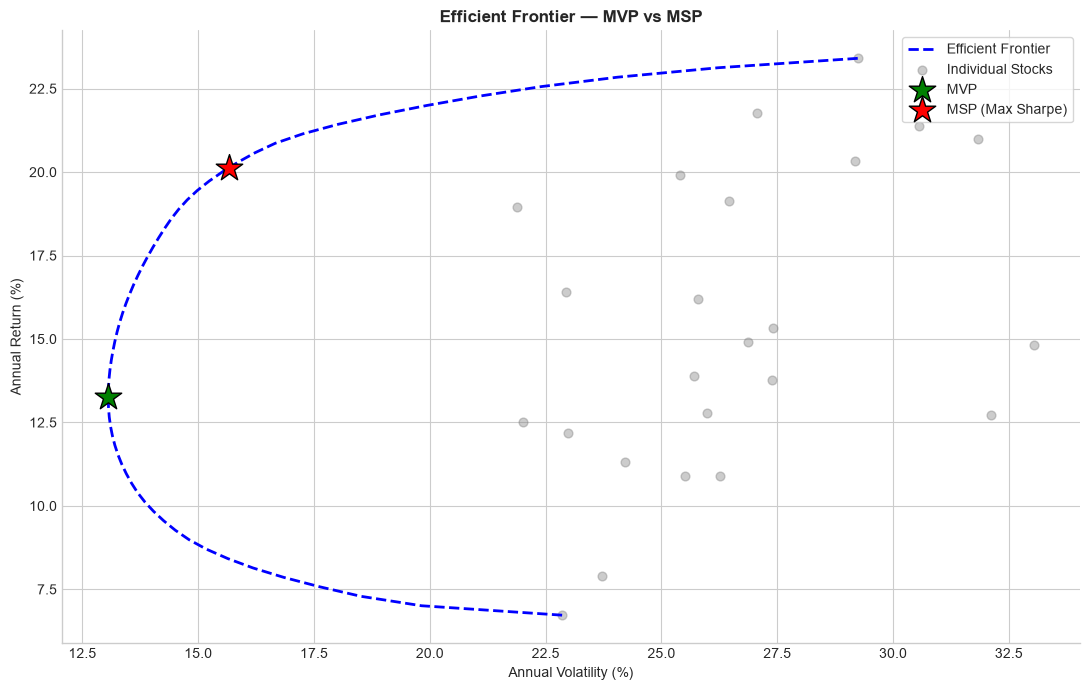

In [6]:
# ============================================================
# STEP 3: Portfolio Optimization — Minimum Variance & Max Sharpe
# ============================================================
from scipy.optimize import minimize
import os

os.makedirs('reports/figures', exist_ok=True)  # for when you move this into the repo

RISK_FREE_RATE = 0.065  # approx. India 10Y G-Sec yield — adjust if you want a different anchor
n_assets = len(final_tickers)

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, rf=RISK_FREE_RATE):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - rf) / vol

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# ---- Long-only, fully invested constraints ----
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))
init_guess = np.array([1/n_assets] * n_assets)

mean_ret_arr = ann_return.values
cov_arr = cov_matrix.values

# ---- Minimum Variance Portfolio (MVP) ----
mvp_res = minimize(portfolio_volatility, init_guess, args=(mean_ret_arr, cov_arr),
                    method='SLSQP', bounds=bounds, constraints=constraints)
mvp_weights = mvp_res.x
mvp_ret, mvp_vol = portfolio_performance(mvp_weights, mean_ret_arr, cov_arr)
mvp_sharpe = (mvp_ret - RISK_FREE_RATE) / mvp_vol

# ---- Maximum Sharpe Portfolio (MSP) ----
msp_res = minimize(neg_sharpe_ratio, init_guess, args=(mean_ret_arr, cov_arr, RISK_FREE_RATE),
                    method='SLSQP', bounds=bounds, constraints=constraints)
msp_weights = msp_res.x
msp_ret, msp_vol = portfolio_performance(msp_weights, mean_ret_arr, cov_arr)
msp_sharpe = (msp_ret - RISK_FREE_RATE) / msp_vol

print("=== Minimum Variance Portfolio (MVP) ===")
print(f"Expected Annual Return: {mvp_ret*100:.2f}%")
print(f"Annual Volatility:      {mvp_vol*100:.2f}%")
print(f"Sharpe Ratio:           {mvp_sharpe:.2f}")

print("\n=== Maximum Sharpe Portfolio (MSP) ===")
print(f"Expected Annual Return: {msp_ret*100:.2f}%")
print(f"Annual Volatility:      {msp_vol*100:.2f}%")
print(f"Sharpe Ratio:           {msp_sharpe:.2f}")

# ---- Weight allocation table ----
weights_df = pd.DataFrame({
    'Sector': [sector_map[t] for t in final_tickers],
    'MVP_Weight_%': mvp_weights * 100,
    'MSP_Weight_%': msp_weights * 100
}, index=final_tickers).sort_values('MSP_Weight_%', ascending=False)

print("\n=== Portfolio Weights (sorted by MSP allocation) ===")
print(weights_df.round(2))

# ---- Efficient Frontier ----
target_returns = np.linspace(ann_return.min(), ann_return.max(), 60)
frontier_vols = []
for target in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_performance(w, mean_ret_arr, cov_arr)[0] - t}
    )
    res = minimize(portfolio_volatility, init_guess, args=(mean_ret_arr, cov_arr),
                    method='SLSQP', bounds=bounds, constraints=cons)
    frontier_vols.append(res.fun if res.success else np.nan)

frontier_df = pd.DataFrame({'Return': target_returns, 'Volatility': frontier_vols}).dropna()

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(frontier_df['Volatility']*100, frontier_df['Return']*100, 'b--', linewidth=2, label='Efficient Frontier')
ax.scatter(ann_vol*100, ann_return*100, c='gray', alpha=0.4, s=40, label='Individual Stocks')
ax.scatter(mvp_vol*100, mvp_ret*100, marker='*', s=400, color='green', edgecolor='black', label='MVP', zorder=5)
ax.scatter(msp_vol*100, msp_ret*100, marker='*', s=400, color='red', edgecolor='black', label='MSP (Max Sharpe)', zorder=5)
ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.set_title('Efficient Frontier — MVP vs MSP', fontweight='bold')
ax.legend(loc='best', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/03_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

=== Constrained MSP (max 15% per stock) ===
Expected Annual Return: 19.91%
Annual Volatility:      15.54%
Sharpe Ratio:           0.86
Number of active positions (>1%): 10

=== Weight Comparison ===
                Sector  MVP_Weight_%  MSP_Weight_%  MSP_Constrained_%
TECHM.NS            IT        0.0000        8.4400            15.0000
CIPLA.NS        Pharma        8.3600        3.6900            15.0000
DABUR.NS          FMCG        5.1000        0.0000            15.0000
ONGC.NS         Energy        1.9500        0.0000            15.0000
BAJAJ-AUTO.NS     Auto        4.2300       14.3400            11.4900
MARUTI.NS         Auto        0.0000        0.0000             8.8700
ICICIBANK.NS   Banking        0.0000       16.6800             5.5400
BRITANNIA.NS      FMCG        5.2100        0.4600             4.9100
SUNPHARMA.NS    Pharma        2.6300        0.0000             4.8700
SBIN.NS        Banking        0.0000        0.0000             3.7900
NESTLEIND.NS      FMCG       11

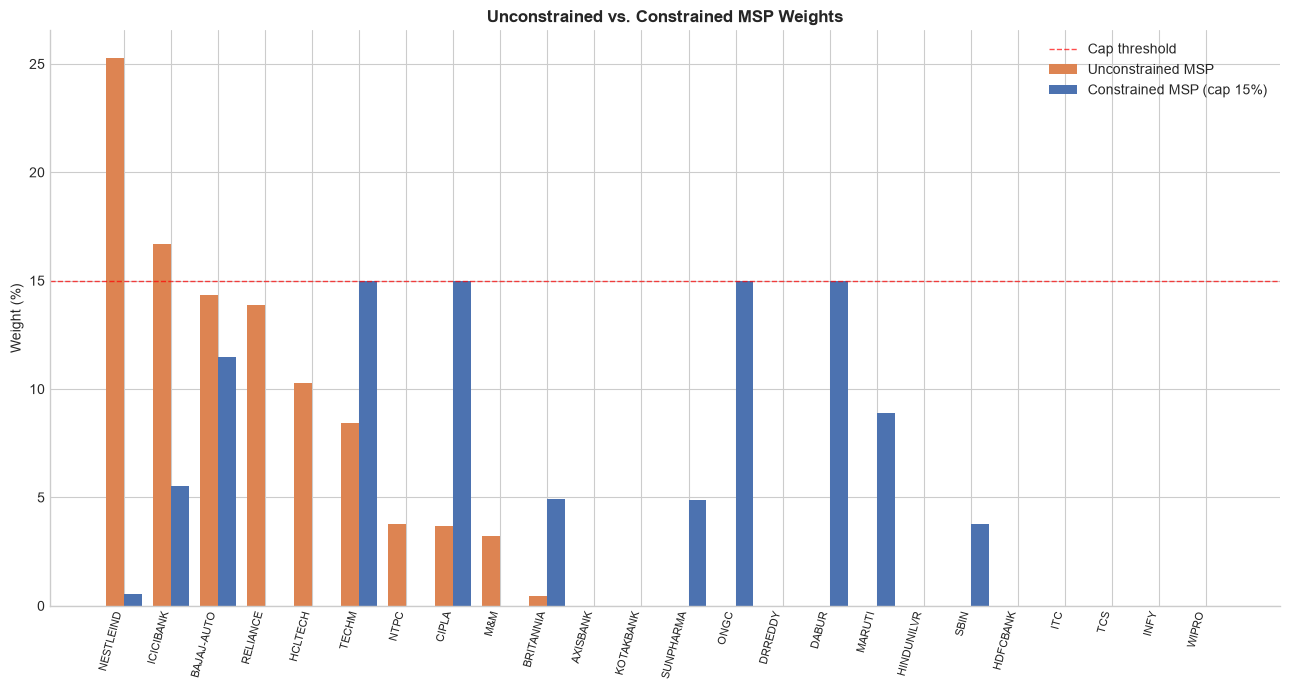

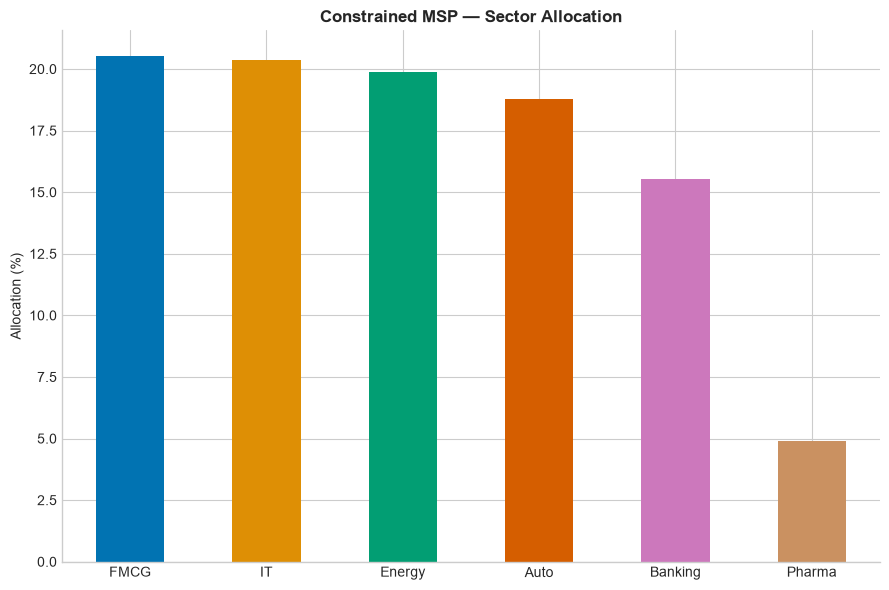

In [10]:
# ============================================================
# STEP 4: Constrained Maximum Sharpe Portfolio (diversification cap)
# ============================================================

MAX_WEIGHT = 0.15  # no single stock > 15% — forces diversification across sectors

constrained_bounds = tuple((0, MAX_WEIGHT) for _ in range(n_assets))

msp_constrained_res = minimize(
    neg_sharpe_ratio, init_guess, args=(mean_ret_arr, cov_arr, RISK_FREE_RATE),
    method='SLSQP', bounds=constrained_bounds, constraints=constraints
)
msp_c_weights = msp_constrained_res.x
msp_c_ret, msp_c_vol = portfolio_performance(msp_c_weights, mean_ret_arr, cov_arr)
msp_c_sharpe = (msp_c_ret - RISK_FREE_RATE) / msp_c_vol

print(f"=== Constrained MSP (max {MAX_WEIGHT*100:.0f}% per stock) ===")
print(f"Expected Annual Return: {msp_c_ret*100:.2f}%")
print(f"Annual Volatility:      {msp_c_vol*100:.2f}%")
print(f"Sharpe Ratio:           {msp_c_sharpe:.2f}")
print(f"Number of active positions (>1%): {(msp_c_weights > 0.01).sum()}")

# ---- Compare unconstrained vs constrained weights ----
weights_df['MSP_Constrained_%'] = msp_c_weights * 100
weights_df = weights_df.sort_values('MSP_Constrained_%', ascending=False)
print("\n=== Weight Comparison ===")
print(weights_df.round(2))

# ---- Sector allocation under constrained MSP ----
sector_alloc = pd.Series(msp_c_weights, index=final_tickers).groupby(sector_map).sum() * 100
sector_alloc = sector_alloc.sort_values(ascending=False)
print("\n=== Sector Allocation (Constrained MSP) ===")
print(sector_alloc.round(2))

# ---- Plot: weight comparison bar chart ----
fig, ax = plt.subplots(figsize=(13, 7))
plot_df = weights_df[['MSP_Weight_%', 'MSP_Constrained_%']].sort_values('MSP_Weight_%', ascending=False)
x = np.arange(len(plot_df))
width = 0.38

ax.bar(x - width/2, plot_df['MSP_Weight_%'], width, label='Unconstrained MSP', color='#DD8452')
ax.bar(x + width/2, plot_df['MSP_Constrained_%'], width, label='Constrained MSP (cap 15%)', color='#4C72B0')
ax.axhline(MAX_WEIGHT*100, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Cap threshold')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('.NS','') for t in plot_df.index], rotation=75, ha='right', fontsize=8)
ax.set_ylabel('Weight (%)')
ax.set_title('Unconstrained vs. Constrained MSP Weights', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/04_constrained_weights.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot: sector allocation pie/bar ----
fig, ax = plt.subplots(figsize=(9, 6))
sector_alloc.plot(kind='bar', ax=ax, color=sns.color_palette("colorblind", len(sector_alloc)))
ax.set_ylabel('Allocation (%)')
ax.set_title('Constrained MSP — Sector Allocation', fontweight='bold')
ax.set_xlabel('')
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/04_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

=== Risk & Performance Summary (Historical, Ex-Post) ===
                       Ann_Return_%  Ann_Volatility_%  Sharpe  Sortino  \
MVP                         13.2660           13.0570  0.5180   0.6960   
MSP (Unconstrained)         20.1290           15.6610  0.8700   1.1390   
MSP (Constrained 15%)       19.9050           15.5370  0.8630   1.1020   

                       Calmar  Max_Drawdown_%  Daily_VaR_95_%  \
MVP                    0.5080        -26.0930          1.1510   
MSP (Unconstrained)    0.5790        -34.7750          1.3840   
MSP (Constrained 15%)  0.5630        -35.3750          1.3490   

                       Daily_CVaR_95_%  Daily_VaR_99_%  Daily_CVaR_99_%  \
MVP                             1.7740          1.8430           3.1560   
MSP (Unconstrained)             2.1630          2.3960           3.8530   
MSP (Constrained 15%)           2.1790          2.3670           3.9220   

                       Skewness  Excess_Kurtosis  
MVP                     -0.2500  

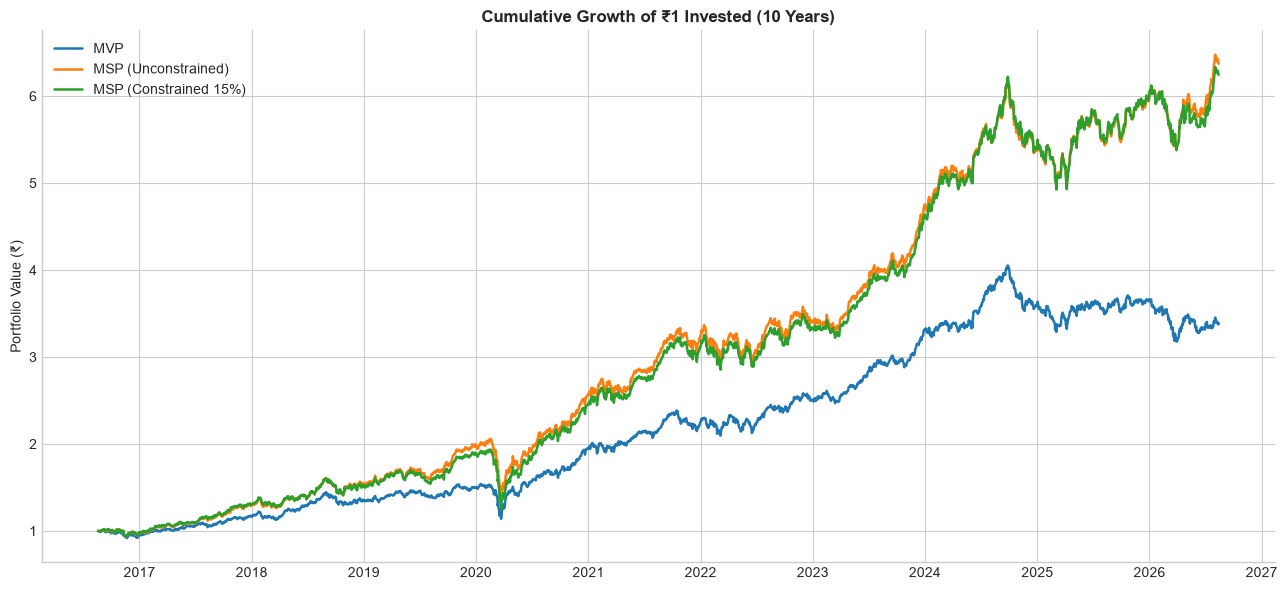

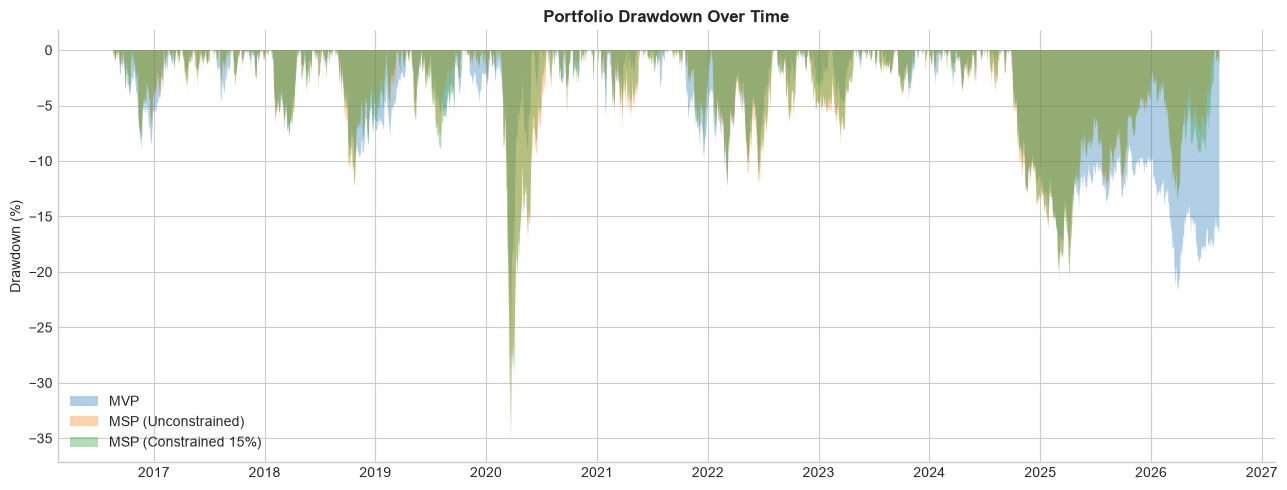

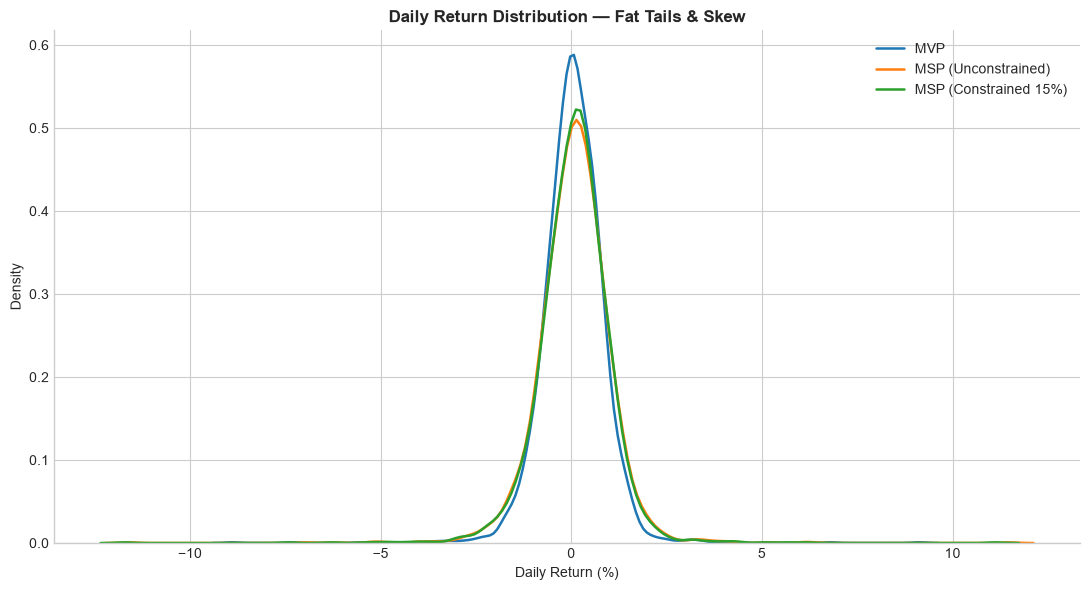

In [11]:
# ============================================================
# STEP 5: Risk Analysis on Historical Portfolio Returns
# ============================================================
from scipy import stats

def portfolio_daily_returns(weights, returns_df):
    """Historical daily return series for a given weight vector."""
    return returns_df.dot(weights)

def max_drawdown(cum_returns):
    """Max drawdown from a cumulative return series (starts at 1.0)."""
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min(), drawdown

def var_cvar(returns, confidence=0.95):
    """Historical VaR and CVaR (Expected Shortfall) at given confidence level."""
    var = -np.percentile(returns, (1 - confidence) * 100)
    cvar = -returns[returns <= -var].mean()
    return var, cvar

def sharpe_sortino_calmar(returns, mdd, rf=RISK_FREE_RATE, trading_days=252):
    ann_ret = returns.mean() * trading_days
    ann_vol = returns.std() * np.sqrt(trading_days)
    sharpe = (ann_ret - rf) / ann_vol
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(trading_days)
    sortino = (ann_ret - rf) / downside_vol if downside_vol > 0 else np.nan
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    return ann_ret, ann_vol, sharpe, sortino, calmar

# ---- Build historical daily return series for each portfolio ----
portfolios = {
    'MVP': mvp_weights,
    'MSP (Unconstrained)': msp_weights,
    'MSP (Constrained 15%)': msp_c_weights
}

risk_results = {}
cum_returns_dict = {}
drawdown_dict = {}

for name, w in portfolios.items():
    port_ret = portfolio_daily_returns(w, daily_returns)
    cum_ret = (1 + port_ret).cumprod()
    mdd, dd_series = max_drawdown(cum_ret)
    var95, cvar95 = var_cvar(port_ret, 0.95)
    var99, cvar99 = var_cvar(port_ret, 0.99)
    skew = stats.skew(port_ret)
    kurt = stats.kurtosis(port_ret)  # excess kurtosis (0 = normal)
    ann_ret, ann_vol, sharpe, sortino, calmar = sharpe_sortino_calmar(port_ret, mdd)

    risk_results[name] = {
        'Ann_Return_%': ann_ret * 100,
        'Ann_Volatility_%': ann_vol * 100,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max_Drawdown_%': mdd * 100,
        'Daily_VaR_95_%': var95 * 100,
        'Daily_CVaR_95_%': cvar95 * 100,
        'Daily_VaR_99_%': var99 * 100,
        'Daily_CVaR_99_%': cvar99 * 100,
        'Skewness': skew,
        'Excess_Kurtosis': kurt
    }
    cum_returns_dict[name] = cum_ret
    drawdown_dict[name] = dd_series

risk_df = pd.DataFrame(risk_results).T
print("=== Risk & Performance Summary (Historical, Ex-Post) ===")
print(risk_df.round(3))

# ---- Plot 1: Cumulative returns ----
fig, ax = plt.subplots(figsize=(13, 6))
for name, cum_ret in cum_returns_dict.items():
    ax.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.8)
ax.set_title('Cumulative Growth of ₹1 Invested (10 Years)', fontweight='bold')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Drawdown ----
fig, ax = plt.subplots(figsize=(13, 5))
for name, dd in drawdown_dict.items():
    ax.fill_between(dd.index, dd.values * 100, 0, alpha=0.35, label=name)
ax.set_title('Portfolio Drawdown Over Time', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 3: Return distribution (fat tails / skew check) ----
fig, ax = plt.subplots(figsize=(11, 6))
for name, w in portfolios.items():
    port_ret = portfolio_daily_returns(w, daily_returns)
    sns.kdeplot(port_ret * 100, label=name, ax=ax, linewidth=1.8)
ax.set_title('Daily Return Distribution — Fat Tails & Skew', fontweight='bold')
ax.set_xlabel('Daily Return (%)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/05_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\choti\anaconda3\envs\riskproject\Lib\site-packages\pandas\core\arrays\datetimelike.py:1339: RuntimeWarning: overflow encountered in scalar multiply
  new_data = np.array([self.freq.base * x for x in new_i8_data])


=== Backtest Results (Monthly Rebalancing + Transaction Costs) ===
                                  Final_Value_(₹100_start)  Ann_Return_%  \
MVP - Rebalanced                                  330.7400       13.0600   
MSP (Unconstrained) - Rebalanced                  626.1200       19.9400   
MSP (Constrained) - Rebalanced                    611.3900       19.6800   
MSP (Constrained) - Buy & Hold                    509.6800       17.9200   

                                  Ann_Volatility_%  Sharpe  Max_Drawdown_%  \
MVP - Rebalanced                           13.0200  0.5000        -25.9800   
MSP (Unconstrained) - Rebalanced           15.6100  0.8600        -34.5400   
MSP (Constrained) - Rebalanced             15.4800  0.8500        -35.1900   
MSP (Constrained) - Buy & Hold             16.0800  0.7100        -35.9500   

                                  Total_Txn_Cost_(₹)  
MVP - Rebalanced                              1.1100  
MSP (Unconstrained) - Rebalanced              1.590

C:\Users\choti\anaconda3\envs\riskproject\Lib\site-packages\pandas\core\arrays\datetimelike.py:1339: RuntimeWarning: overflow encountered in scalar multiply
  new_data = np.array([self.freq.base * x for x in new_i8_data])



Cost drag on Constrained MSP: ₹614.72 (no cost) → ₹611.39 (with cost) = 0.54% eroded by transaction costs


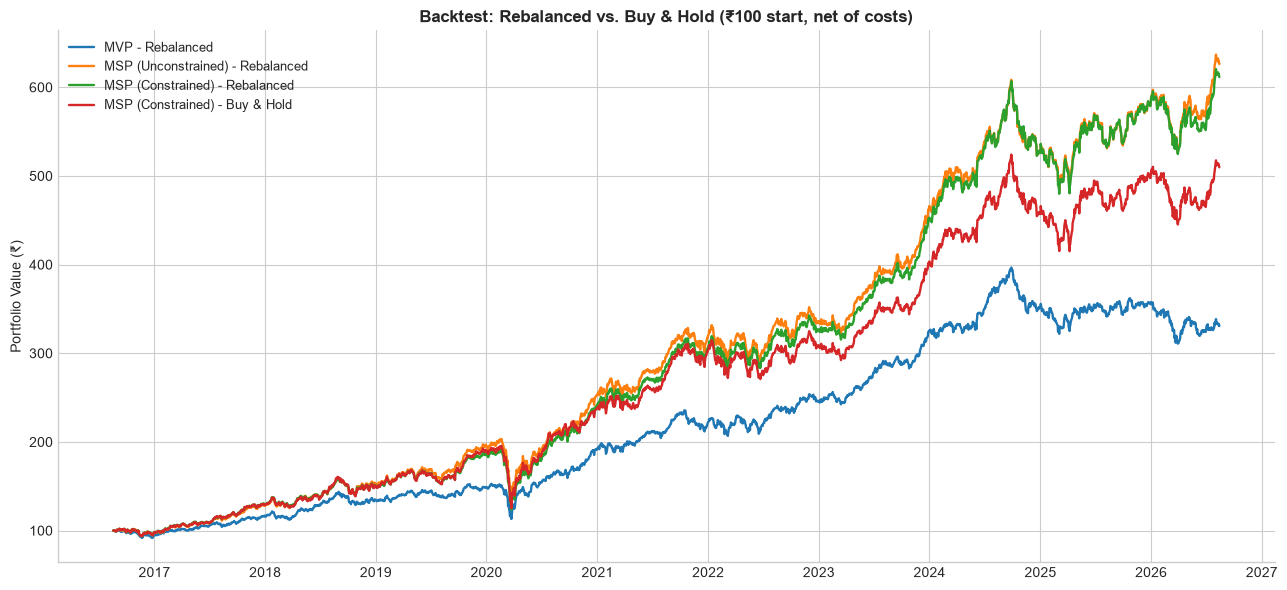

In [12]:
# ============================================================
# STEP 6: Backtest — Monthly Rebalancing + Transaction Costs
# ============================================================

TXN_COST = 0.001  # 0.1% per unit of turnover (blended brokerage + STT + slippage)

def backtest_portfolio(prices, target_weights, rebalance=True, txn_cost=TXN_COST, initial_capital=100):
    """
    Simulates holding a portfolio that drifts with daily prices, and — if
    rebalance=True — is reset to target_weights at each month-end, paying
    transaction costs proportional to turnover.
    """
    tickers = prices.columns
    dates = prices.index
    daily_ret = prices.pct_change().fillna(0)

    # month-end rebalance flags (last trading day of each month)
    is_month_end = pd.Series(dates).dt.to_period('M').diff().fillna(pd.Timedelta(0)).values
    month_of_date = pd.Series(dates, index=dates).dt.to_period('M')
    rebal_flags = month_of_date != month_of_date.shift(1)  # True on first day of new month
    rebal_flags.iloc[0] = False  # don't rebalance on day 0, already at target

    holdings_value = pd.Series(target_weights * initial_capital, index=tickers)
    portfolio_values = []
    total_cost_paid = 0.0

    for i, date in enumerate(dates):
        if i > 0:
            holdings_value = holdings_value * (1 + daily_ret.loc[date])

        current_total = holdings_value.sum()

        if rebalance and rebal_flags.loc[date] and i > 0:
            target_value = target_weights * current_total
            turnover = np.abs(target_value - holdings_value.values).sum() / current_total
            cost = turnover * txn_cost * current_total
            total_cost_paid += cost
            current_total -= cost
            holdings_value = pd.Series(target_weights * current_total, index=tickers)

        portfolio_values.append(holdings_value.sum())

    portfolio_series = pd.Series(portfolio_values, index=dates)
    return portfolio_series, total_cost_paid

# ---- Run backtests: rebalanced (with costs) vs buy & hold (no rebalancing) ----
backtest_configs = {
    'MVP - Rebalanced': (mvp_weights, True),
    'MSP (Unconstrained) - Rebalanced': (msp_weights, True),
    'MSP (Constrained) - Rebalanced': (msp_c_weights, True),
    'MSP (Constrained) - Buy & Hold': (msp_c_weights, False),
}

backtest_results = {}
backtest_series = {}

for name, (w, rebal) in backtest_configs.items():
    series, cost = backtest_portfolio(prices, w, rebalance=rebal, txn_cost=TXN_COST)
    port_ret = series.pct_change().dropna()
    cum = series / series.iloc[0]
    mdd, _ = max_drawdown(cum)
    ann_ret, ann_vol, sharpe, sortino, calmar = sharpe_sortino_calmar(port_ret, mdd)

    backtest_results[name] = {
        'Final_Value_(₹100_start)': series.iloc[-1],
        'Ann_Return_%': ann_ret * 100,
        'Ann_Volatility_%': ann_vol * 100,
        'Sharpe': sharpe,
        'Max_Drawdown_%': mdd * 100,
        'Total_Txn_Cost_(₹)': cost
    }
    backtest_series[name] = series

backtest_df = pd.DataFrame(backtest_results).T
print("=== Backtest Results (Monthly Rebalancing + Transaction Costs) ===")
print(backtest_df.round(2))

# ---- Also compare: MSP constrained rebalanced WITH vs WITHOUT costs, to isolate cost impact ----
series_no_cost, _ = backtest_portfolio(prices, msp_c_weights, rebalance=True, txn_cost=0.0)
final_no_cost = series_no_cost.iloc[-1]
final_with_cost = backtest_series['MSP (Constrained) - Rebalanced'].iloc[-1]
print(f"\nCost drag on Constrained MSP: ₹{final_no_cost:.2f} (no cost) → ₹{final_with_cost:.2f} (with cost) "
      f"= {(final_no_cost - final_with_cost)/final_no_cost*100:.2f}% eroded by transaction costs")

# ---- Plot: backtest comparison ----
fig, ax = plt.subplots(figsize=(13, 6))
for name, series in backtest_series.items():
    ax.plot(series.index, series.values, label=name, linewidth=1.7)
ax.set_title('Backtest: Rebalanced vs. Buy & Hold (₹100 start, net of costs)', fontweight='bold')
ax.set_ylabel('Portfolio Value (₹)')
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/06_backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

=== FINAL SUMMARY: Expected (Mean-Variance) vs Historical vs Backtested ===
                       Expected_Return_%  Expected_Sharpe  \
Strategy                                                    
MVP                              13.2700           0.5200   
MSP (Unconstrained)              20.1300           0.8700   
MSP (Constrained 15%)            19.9100           0.8600   

                       Historical_Return_%  Historical_Sharpe  Max_Drawdown_%  \
Strategy                                                                        
MVP                                13.2700             0.5200        -26.0900   
MSP (Unconstrained)                20.1300             0.8700        -34.7800   
MSP (Constrained 15%)              19.9100             0.8600        -35.3700   

                       Backtest_Return_%  Backtest_Sharpe  
Strategy                                                   
MVP                              13.0600           0.5000  
MSP (Unconstrained)             

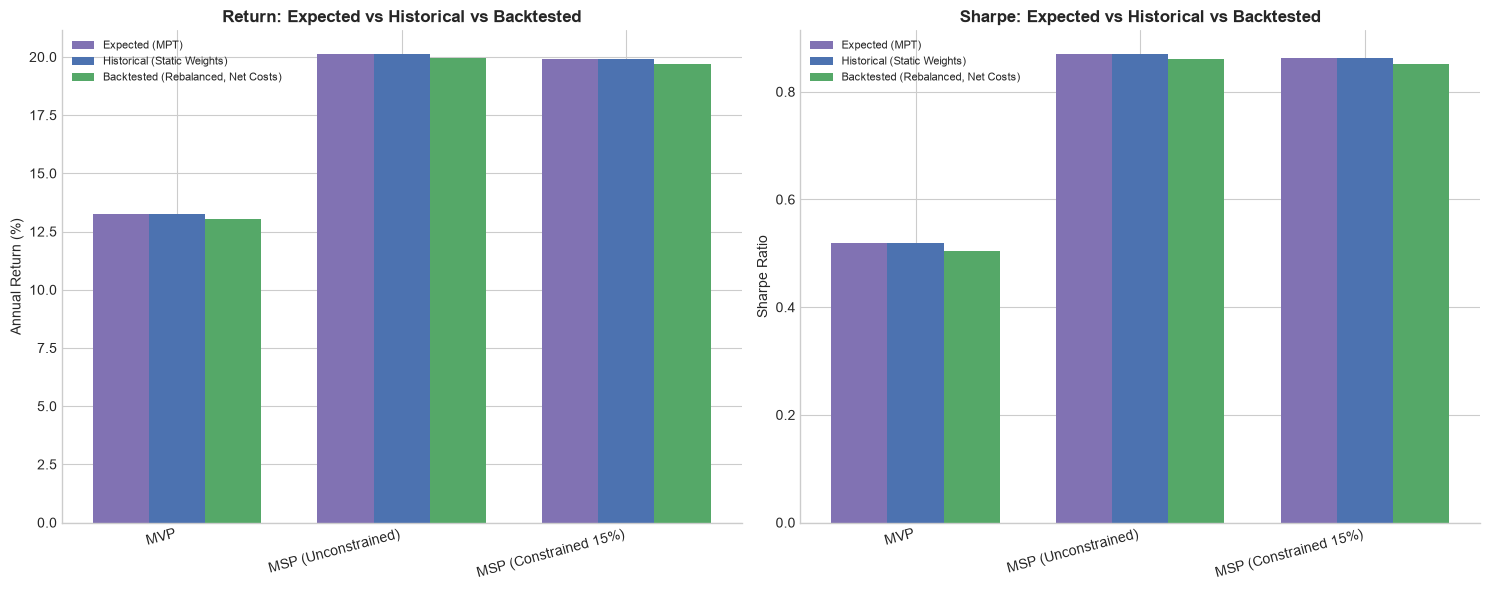


Saved: portfolio_weights.csv, risk_metrics.csv, backtest_results.csv, final_summary.csv


In [13]:
# ============================================================
# STEP 7: Consolidated Results Summary (Expected vs. Realized)
# ============================================================

summary = pd.DataFrame({
    'Strategy': ['MVP', 'MSP (Unconstrained)', 'MSP (Constrained 15%)'],
    'Expected_Return_%': [mvp_ret*100, msp_ret*100, msp_c_ret*100],
    'Expected_Sharpe': [mvp_sharpe, msp_sharpe, msp_c_sharpe],
    'Historical_Return_%': [risk_df.loc['MVP','Ann_Return_%'],
                             risk_df.loc['MSP (Unconstrained)','Ann_Return_%'],
                             risk_df.loc['MSP (Constrained 15%)','Ann_Return_%']],
    'Historical_Sharpe': [risk_df.loc['MVP','Sharpe'],
                           risk_df.loc['MSP (Unconstrained)','Sharpe'],
                           risk_df.loc['MSP (Constrained 15%)','Sharpe']],
    'Max_Drawdown_%': [risk_df.loc['MVP','Max_Drawdown_%'],
                        risk_df.loc['MSP (Unconstrained)','Max_Drawdown_%'],
                        risk_df.loc['MSP (Constrained 15%)','Max_Drawdown_%']],
    'Backtest_Return_%': [backtest_df.loc['MVP - Rebalanced','Ann_Return_%'],
                           backtest_df.loc['MSP (Unconstrained) - Rebalanced','Ann_Return_%'],
                           backtest_df.loc['MSP (Constrained) - Rebalanced','Ann_Return_%']],
    'Backtest_Sharpe': [backtest_df.loc['MVP - Rebalanced','Sharpe'],
                         backtest_df.loc['MSP (Unconstrained) - Rebalanced','Sharpe'],
                         backtest_df.loc['MSP (Constrained) - Rebalanced','Sharpe']],
}).set_index('Strategy')

print("=== FINAL SUMMARY: Expected (Mean-Variance) vs Historical vs Backtested ===")
print(summary.round(2))

# ---- Summary bar chart ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(summary))
width = 0.25
axes[0].bar(x - width, summary['Expected_Return_%'], width, label='Expected (MPT)', color='#8172B3')
axes[0].bar(x, summary['Historical_Return_%'], width, label='Historical (Static Weights)', color='#4C72B0')
axes[0].bar(x + width, summary['Backtest_Return_%'], width, label='Backtested (Rebalanced, Net Costs)', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary.index, rotation=15, ha='right')
axes[0].set_ylabel('Annual Return (%)')
axes[0].set_title('Return: Expected vs Historical vs Backtested', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(x - width, summary['Expected_Sharpe'], width, label='Expected (MPT)', color='#8172B3')
axes[1].bar(x, summary['Historical_Sharpe'], width, label='Historical (Static Weights)', color='#4C72B0')
axes[1].bar(x + width, summary['Backtest_Sharpe'], width, label='Backtested (Rebalanced, Net Costs)', color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary.index, rotation=15, ha='right')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Sharpe: Expected vs Historical vs Backtested', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/07_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Save all key tables to CSV for the repo ----
import os
os.makedirs('reports', exist_ok=True)
weights_df.to_csv('reports/portfolio_weights.csv')
risk_df.to_csv('reports/risk_metrics.csv')
backtest_df.to_csv('reports/backtest_results.csv')
summary.to_csv('reports/final_summary.csv')
print("\nSaved: portfolio_weights.csv, risk_metrics.csv, backtest_results.csv, final_summary.csv")